In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
results = pd.read_csv('results/fewshot_size.csv')

In [ ]:
results

In [3]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import ast
import numpy as np

# Create empty columns for the metrics
results['R-squared_x'] = np.nan
results['RMSE_x'] = np.nan
results['MAPE_x'] = np.nan

for idx, row_data in results.iterrows():
    # Convert string representations to actual list/array objects if needed
    if isinstance(row_data['GT Counts'], str):
        gt_counts = np.array(ast.literal_eval(row_data['GT Counts']))
    else:
        gt_counts = row_data['GT Counts']
        
    if isinstance(row_data['Pred Counts'], str):
        pred_counts = np.array(ast.literal_eval(row_data['Pred Counts']))
    else:
        pred_counts = row_data['Pred Counts']
    
    # Calculate metrics
    r2 = r2_score(gt_counts, pred_counts)
    rmse = root_mean_squared_error(gt_counts, pred_counts)
    mape = mean_absolute_percentage_error(gt_counts, pred_counts)
    
    # Update the DataFrame with the metrics
    results.at[idx, 'R-squared_x'] = r2
    results.at[idx, 'RMSE_x'] = rmse
    results.at[idx, 'MAPE_x'] = mape * 100

In [25]:
results['R-squared_y'] = results['R-squared_x'] - results['R-Squared']
results['RMSE_y'] = results['RMSE_x'] - results['RMSE']
results['MAPE_y'] = results['MAPE_x'] - results['MAPE']

In [26]:
results['R-squared_y'].unique(), results['RMSE_y'].unique(), results['MAPE_y'].unique()

(array([ 0.00000000e+00, -3.55271368e-15,  3.55271368e-15,  2.84217094e-14,
         1.77635684e-15, -8.88178420e-16, -2.84217094e-14, -1.77635684e-15,
        -5.68434189e-14, -4.44089210e-16, -1.13686838e-13,  8.88178420e-16,
         4.44089210e-16, -1.42108547e-14,  7.10542736e-15, -5.55111512e-17]),
 array([ 0.00000000e+00,  1.77635684e-15, -1.77635684e-15,  8.88178420e-16,
         7.10542736e-15, -3.55271368e-15, -8.88178420e-16,  3.55271368e-15,
        -4.44089210e-16]),
 array([-125.67449634,  -74.08026557,  -81.40491071,  -86.91473214,
         -90.07068452,  -91.17068452,  -92.08735119,  -92.6766369 ,
         -94.2578869 ,  -95.17455357,  -95.69017857,  -97.31071429,
        -331.20403846,  -65.51123626,  -60.66953297,  -65.57510989,
         -68.29675824,  -68.25883242,  -68.63567308,  -71.40335165,
         -74.73870879,  -76.68924451,  -80.64710165,  -83.34210165,
         -88.46649725,  -95.76      ,  -97.44      , -103.67043269,
         -96.64285714,  -97.08482143,  

In [4]:
results['MAPE'] = results['MAPE_x']

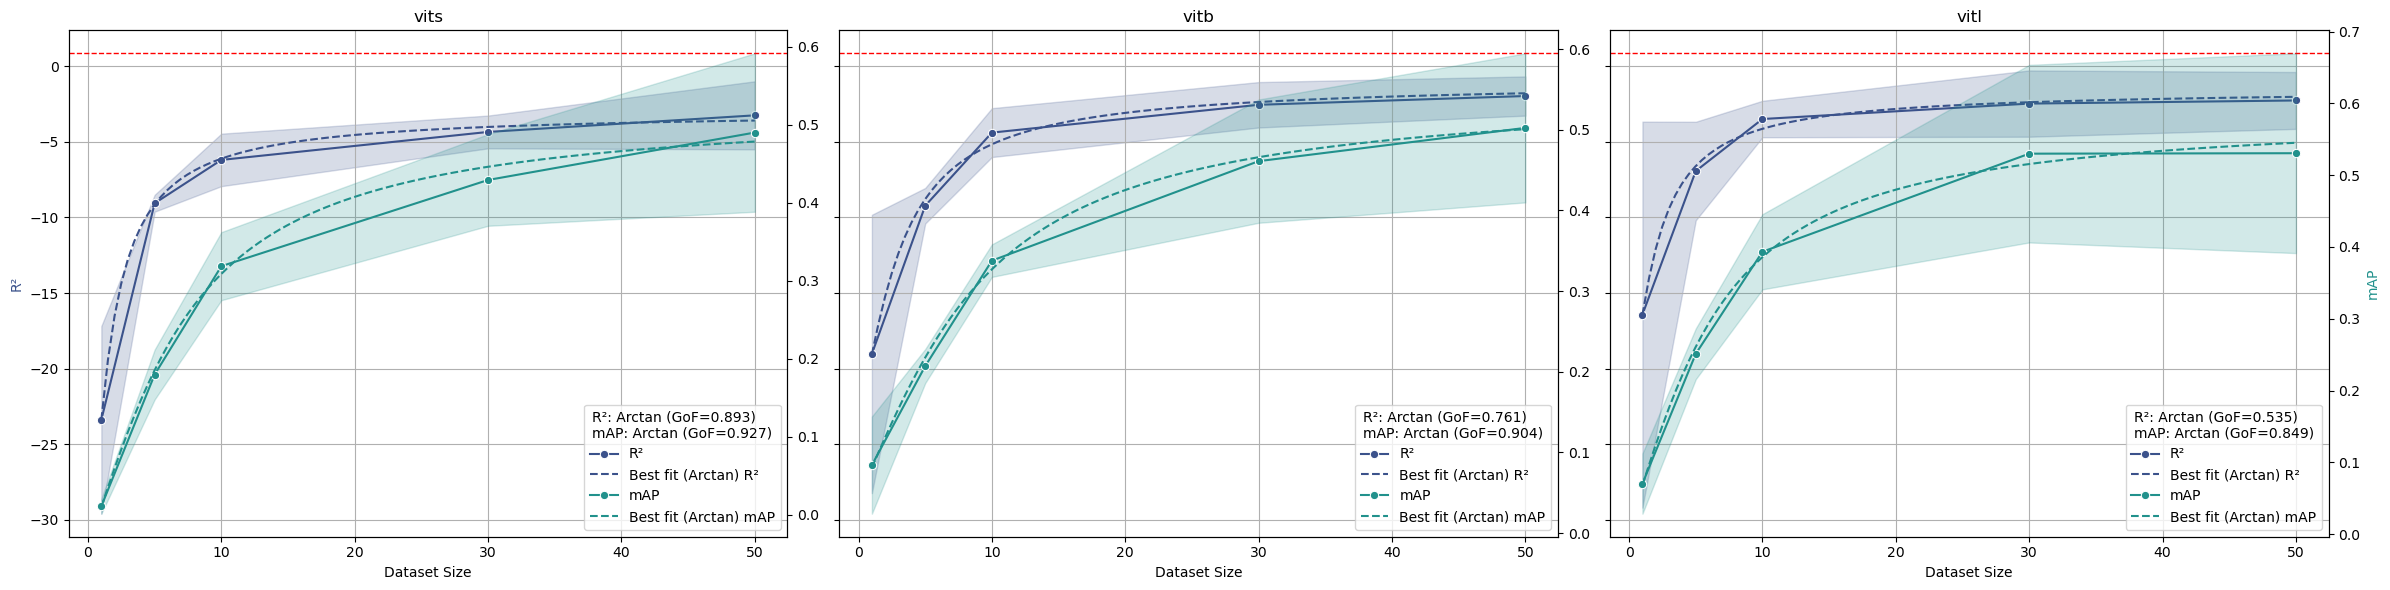

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

models = ['vits', 'vitb', 'vitl']

# Initialize the filtered DataFrame
filtered_df = results.copy()

# Set NaN values in the 'R-Squared' column to 0
filtered_df['R-Squared'] = filtered_df['R-Squared'].fillna(0)

# Filter the DataFrame to include the specified models
filtered_df = filtered_df[filtered_df['Model'].isin(models)]

# Group by 'Dataset', 'model', and 'Dataset_size' and select the observation with the highest 'R-Squared' value
filtered_df = filtered_df.loc[filtered_df.groupby(['Dataset', 'Model', 'Shots'])['R-Squared'].idxmax()]

# Sort by Dataset size
filtered_df = filtered_df.sort_values(by='Shots')

# Define custom colors for each metric using the Viridis colormap
viridis = sns.color_palette("viridis", 3)
metric_colors = {'R-Squared': viridis[0], 'AP (IoU=.50)': viridis[1]}

# Define fitting functions
def log_func(x, a, b):
    return a * np.log(x) + b

def arctan_func(x, a, b, c):
    return a * np.arctan(b * x) + c

def root_func(x, a, b, c):
    return a * np.power(x, 1/b) + c

# Create subplots
fig, axes = plt.subplots(1, len(models), figsize=(24, 6), sharey=True)

for i, (ax, model) in enumerate(zip(axes, models)):
    # Filter to single model
    model_data = filtered_df[filtered_df['Model'] == model]
    
    # Plot R-Squared
    sns.lineplot(
        x='Shots', 
        y='R-Squared', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['R-Squared'],
        ax=ax,
        label='R²',
        legend=False
    )
    
    # Fit functions for R-Squared vs Dataset_size
    x_data = model_data['Shots']
    y_data = model_data['R-Squared']
    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
    
    # Initialize variables to track best fit
    best_r2_fit = None
    best_r2_score = -np.inf
    best_r2_name = ""
    
    # Try logarithmic fit
    try:
        popt_log, _ = curve_fit(log_func, x_data, y_data)
        y_fit_log = log_func(x_fit, *popt_log)
        r2_log = r2_score(y_data, log_func(x_data, *popt_log))
        if r2_log > best_r2_score:
            best_r2_fit = y_fit_log
            best_r2_score = r2_log
            best_r2_name = "Logarithmic"
    except:
        r2_log = -np.inf
    
    # Try arctan fit
    try:
        popt_arctan, _ = curve_fit(arctan_func, x_data, y_data)
        y_fit_arctan = arctan_func(x_fit, *popt_arctan)
        r2_arctan = r2_score(y_data, arctan_func(x_data, *popt_arctan))
        if r2_arctan > best_r2_score:
            best_r2_fit = y_fit_arctan
            best_r2_score = r2_arctan
            best_r2_name = "Arctan"
    except:
        r2_arctan = -np.inf
    
    # Try root fit
    try:
        p0 = [1, 2, 0]  # Initial parameter guess
        popt_root, _ = curve_fit(root_func, x_data, y_data, p0=p0)
        y_fit_root = root_func(x_fit, *popt_root)
        r2_root = r2_score(y_data, root_func(x_data, *popt_root))
        if r2_root > best_r2_score:
            best_r2_fit = y_fit_root
            best_r2_score = r2_root
            best_r2_name = "Algebraic Root"
    except:
        r2_root = -np.inf
    
    # Plot the best fit for R-Squared
    ax.plot(x_fit, best_r2_fit, color=metric_colors['R-Squared'], linestyle='--', 
            label=f'Best fit ({best_r2_name}) R²')
    
    # Create a twin Axes sharing the x-axis
    ax2 = ax.twinx()
    
    # Plot ap_iou_50_95
    sns.lineplot(
        x='Shots', 
        y='AP (IoU=.50)', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['AP (IoU=.50)'],
        ax=ax2,
        label='mAP',
        legend=False
    )
    
    # Fit functions for ap_iou_50_95 vs Dataset_size
    y_data_ap = model_data['AP (IoU=.50)']
    
    # Initialize variables to track best fit
    best_ap_fit = None
    best_ap_score = -np.inf
    best_ap_name = ""
    
    # Try logarithmic fit
    try:
        popt_log_ap, _ = curve_fit(log_func, x_data, y_data_ap)
        y_fit_log_ap = log_func(x_fit, *popt_log_ap)
        r2_log_ap = r2_score(y_data_ap, log_func(x_data, *popt_log_ap))
        if r2_log_ap > best_ap_score:
            best_ap_fit = y_fit_log_ap
            best_ap_score = r2_log_ap
            best_ap_name = "Logarithmic"
    except:
        r2_log_ap = -np.inf
    
    # Try arctan fit
    try:
        popt_arctan_ap, _ = curve_fit(arctan_func, x_data, y_data_ap)
        y_fit_arctan_ap = arctan_func(x_fit, *popt_arctan_ap)
        r2_arctan_ap = r2_score(y_data_ap, arctan_func(x_data, *popt_arctan_ap))
        if r2_arctan_ap > best_ap_score:
            best_ap_fit = y_fit_arctan_ap
            best_ap_score = r2_arctan_ap
            best_ap_name = "Arctan"
    except:
        r2_arctan_ap = -np.inf
    
    # Try root fit
    try:
        popt_root_ap, _ = curve_fit(root_func, x_data, y_data_ap, p0=[1, 2, 0])
        y_fit_root_ap = root_func(x_fit, *popt_root_ap)
        r2_root_ap = r2_score(y_data_ap, root_func(x_data, *popt_root_ap))
        if r2_root_ap > best_ap_score:
            best_ap_fit = y_fit_root_ap
            best_ap_score = r2_root_ap
            best_ap_name = "Algebraic Root"
    except:
        r2_root_ap = -np.inf
    
    # Plot the best fit for ap_iou_50_95
    ax2.plot(x_fit, best_ap_fit, color=metric_colors['AP (IoU=.50)'], linestyle='--', 
             label=f'Best fit ({best_ap_name}) mAP')
    
    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    combined_lines = lines + lines2
    combined_labels = labels + labels2
    
    # Include best fit function name and R-squared in the legend title
    combined_title = f'R²: {best_r2_name} (GoF={best_r2_score:.3f})\nmAP: {best_ap_name} (GoF={best_ap_score:.3f})'
    ax2.legend(combined_lines, combined_labels, title=combined_title, loc='lower right')
    
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1)
    # ax.set_ylim(-1, 1)
    ax.set_title(f'{model}')
    ax.set_xlabel('Dataset Size')
    if i == 0:
        ax.set_ylabel('R²', color=metric_colors['R-Squared'])
    else:
        ax.set_ylabel('')
    ax.grid(True)
    
    if i == len(models) - 1:
        ax2.set_ylabel('mAP', color=metric_colors['AP (IoU=.50)'])
    else:
        ax2.set_ylabel('')
    ax2.grid(False)

plt.tight_layout()

# Save as PDF
plt.savefig('MDPI_template/Plots/r2_ap_vs_shots_cdvito.pdf', format='pdf')
# plt.show()

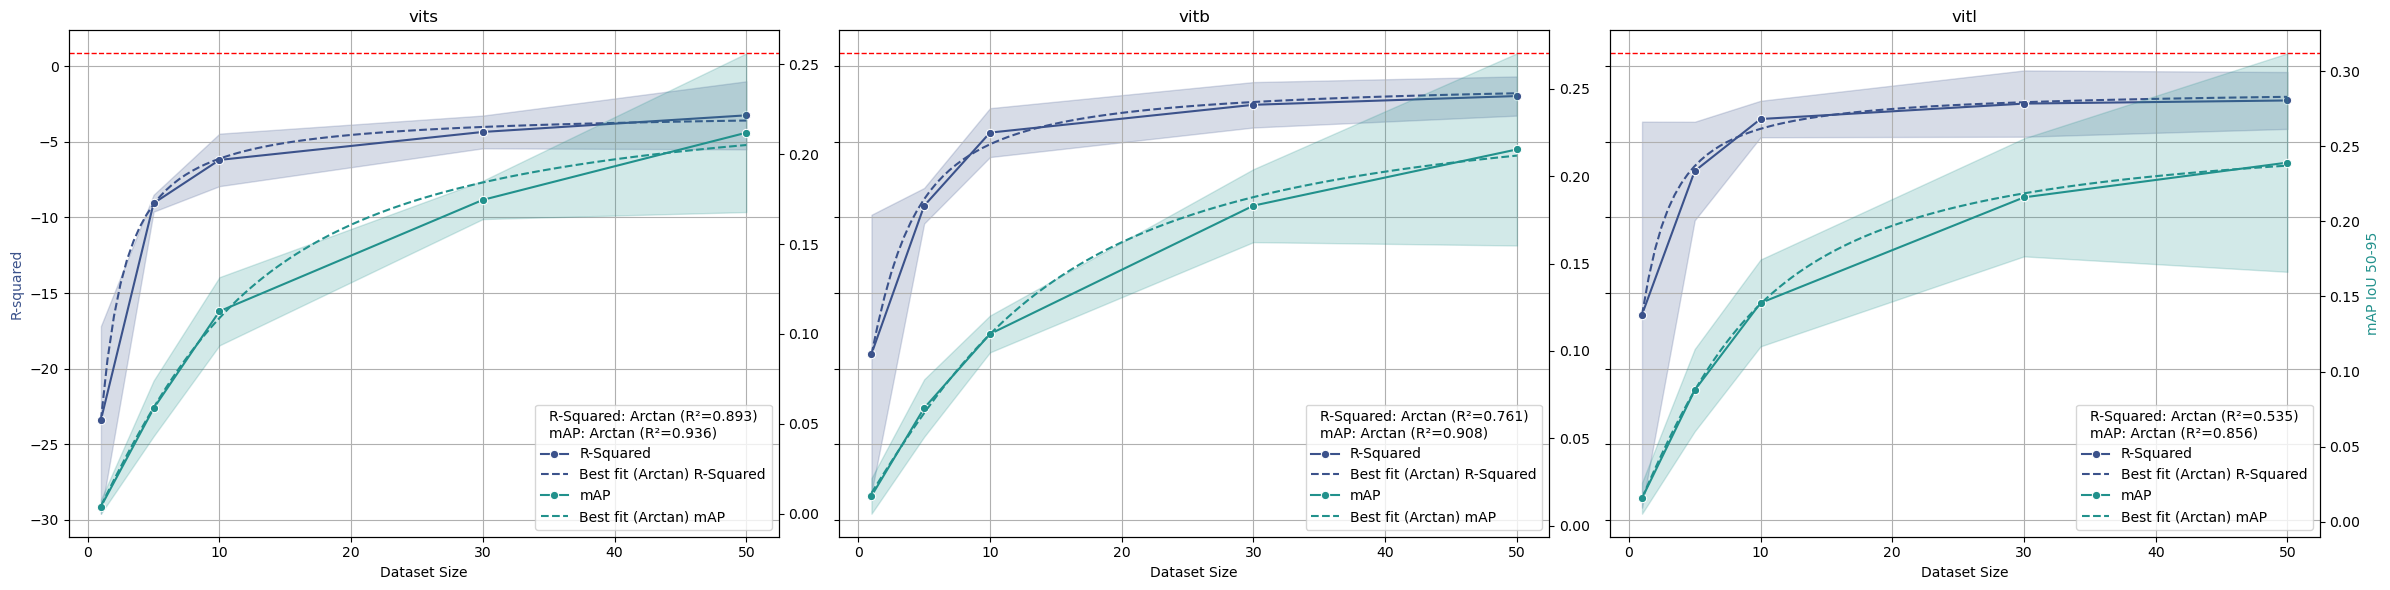

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

models = ['vits', 'vitb', 'vitl']

# Initialize the filtered DataFrame
filtered_df = results.copy()

# Set NaN values in the 'R-Squared' column to 0
filtered_df['R-Squared'] = filtered_df['R-Squared'].fillna(0)

# Filter the DataFrame to include the specified models
filtered_df = filtered_df[filtered_df['Model'].isin(models)]

# Group by 'Dataset', 'model', and 'Dataset_size' and select the observation with the highest 'R-Squared' value
filtered_df = filtered_df.loc[filtered_df.groupby(['Dataset', 'Model', 'Shots'])['R-Squared'].idxmax()]

# Sort by Dataset size
filtered_df = filtered_df.sort_values(by='Shots')

# Define custom colors for each metric using the Viridis colormap
viridis = sns.color_palette("viridis", 3)
metric_colors = {'R-Squared': viridis[0], 'AP (IoU=.50:.95)': viridis[1]}

# Define fitting functions
def log_func(x, a, b):
    return a * np.log(x) + b

def arctan_func(x, a, b, c):
    return a * np.arctan(b * x) + c

def root_func(x, a, b, c):
    return a * np.power(x, 1/b) + c

# Create subplots
fig, axes = plt.subplots(1, len(models), figsize=(24, 6), sharey=True)

for i, (ax, model) in enumerate(zip(axes, models)):
    # Filter to single model
    model_data = filtered_df[filtered_df['Model'] == model]
    
    # Plot R-Squared
    sns.lineplot(
        x='Shots', 
        y='R-Squared', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['R-Squared'],
        ax=ax,
        label='R-Squared',
        legend=False
    )
    
    # Fit functions for R-Squared vs Dataset_size
    x_data = model_data['Shots']
    y_data = model_data['R-Squared']
    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
    
    # Initialize variables to track best fit
    best_r2_fit = None
    best_r2_score = -np.inf
    best_r2_name = ""
    
    # Try logarithmic fit
    try:
        popt_log, _ = curve_fit(log_func, x_data, y_data)
        y_fit_log = log_func(x_fit, *popt_log)
        r2_log = r2_score(y_data, log_func(x_data, *popt_log))
        if r2_log > best_r2_score:
            best_r2_fit = y_fit_log
            best_r2_score = r2_log
            best_r2_name = "Logarithmic"
    except:
        r2_log = -np.inf
    
    # Try arctan fit
    try:
        popt_arctan, _ = curve_fit(arctan_func, x_data, y_data)
        y_fit_arctan = arctan_func(x_fit, *popt_arctan)
        r2_arctan = r2_score(y_data, arctan_func(x_data, *popt_arctan))
        if r2_arctan > best_r2_score:
            best_r2_fit = y_fit_arctan
            best_r2_score = r2_arctan
            best_r2_name = "Arctan"
    except:
        r2_arctan = -np.inf
    
    # Try root fit
    try:
        p0 = [1, 2, 0]  # Initial parameter guess
        popt_root, _ = curve_fit(root_func, x_data, y_data, p0=p0)
        y_fit_root = root_func(x_fit, *popt_root)
        r2_root = r2_score(y_data, root_func(x_data, *popt_root))
        if r2_root > best_r2_score:
            best_r2_fit = y_fit_root
            best_r2_score = r2_root
            best_r2_name = "Algebraic Root"
    except:
        r2_root = -np.inf
    
    # Plot the best fit for R-Squared
    ax.plot(x_fit, best_r2_fit, color=metric_colors['R-Squared'], linestyle='--', 
            label=f'Best fit ({best_r2_name}) R-Squared')
    
    # Create a twin Axes sharing the x-axis
    ax2 = ax.twinx()
    
    # Plot ap_iou_50_95
    sns.lineplot(
        x='Shots', 
        y='AP (IoU=.50:.95)', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['AP (IoU=.50:.95)'],
        ax=ax2,
        label='mAP',
        legend=False
    )
    
    # Fit functions for ap_iou_50_95 vs Dataset_size
    y_data_ap = model_data['AP (IoU=.50:.95)']
    
    # Initialize variables to track best fit
    best_ap_fit = None
    best_ap_score = -np.inf
    best_ap_name = ""
    
    # Try logarithmic fit
    try:
        popt_log_ap, _ = curve_fit(log_func, x_data, y_data_ap)
        y_fit_log_ap = log_func(x_fit, *popt_log_ap)
        r2_log_ap = r2_score(y_data_ap, log_func(x_data, *popt_log_ap))
        if r2_log_ap > best_ap_score:
            best_ap_fit = y_fit_log_ap
            best_ap_score = r2_log_ap
            best_ap_name = "Logarithmic"
    except:
        r2_log_ap = -np.inf
    
    # Try arctan fit
    try:
        popt_arctan_ap, _ = curve_fit(arctan_func, x_data, y_data_ap)
        y_fit_arctan_ap = arctan_func(x_fit, *popt_arctan_ap)
        r2_arctan_ap = r2_score(y_data_ap, arctan_func(x_data, *popt_arctan_ap))
        if r2_arctan_ap > best_ap_score:
            best_ap_fit = y_fit_arctan_ap
            best_ap_score = r2_arctan_ap
            best_ap_name = "Arctan"
    except:
        r2_arctan_ap = -np.inf
    
    # Try root fit
    try:
        popt_root_ap, _ = curve_fit(root_func, x_data, y_data_ap, p0=[1, 2, 0])
        y_fit_root_ap = root_func(x_fit, *popt_root_ap)
        r2_root_ap = r2_score(y_data_ap, root_func(x_data, *popt_root_ap))
        if r2_root_ap > best_ap_score:
            best_ap_fit = y_fit_root_ap
            best_ap_score = r2_root_ap
            best_ap_name = "Algebraic Root"
    except:
        r2_root_ap = -np.inf
    
    # Plot the best fit for ap_iou_50_95
    ax2.plot(x_fit, best_ap_fit, color=metric_colors['AP (IoU=.50:.95)'], linestyle='--', 
             label=f'Best fit ({best_ap_name}) mAP')
    
    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    combined_lines = lines + lines2
    combined_labels = labels + labels2
    
    # Include best fit function name and R-squared in the legend title
    combined_title = f'R-Squared: {best_r2_name} (GoF={best_r2_score:.3f})\nmAP: {best_ap_name} (R²={best_ap_score:.3f})'
    ax2.legend(combined_lines, combined_labels, title=combined_title, loc='lower right')
    
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1)
    # ax.set_ylim(-1, 1)
    ax.set_title(f'{model}')
    ax.set_xlabel('Dataset Size')
    if i == 0:
        ax.set_ylabel('R-squared', color=metric_colors['R-Squared'])
    else:
        ax.set_ylabel('')
    ax.grid(True)
    
    if i == len(models) - 1:
        ax2.set_ylabel('mAP IoU 50-95', color=metric_colors['AP (IoU=.50:.95)'])
    else:
        ax2.set_ylabel('')
    ax2.grid(False)

plt.tight_layout()

# Save as PDF
plt.savefig('MDPI_template/Plots/r2_ap_vs_shots_cdvito.pdf', format='pdf')
# plt.show()

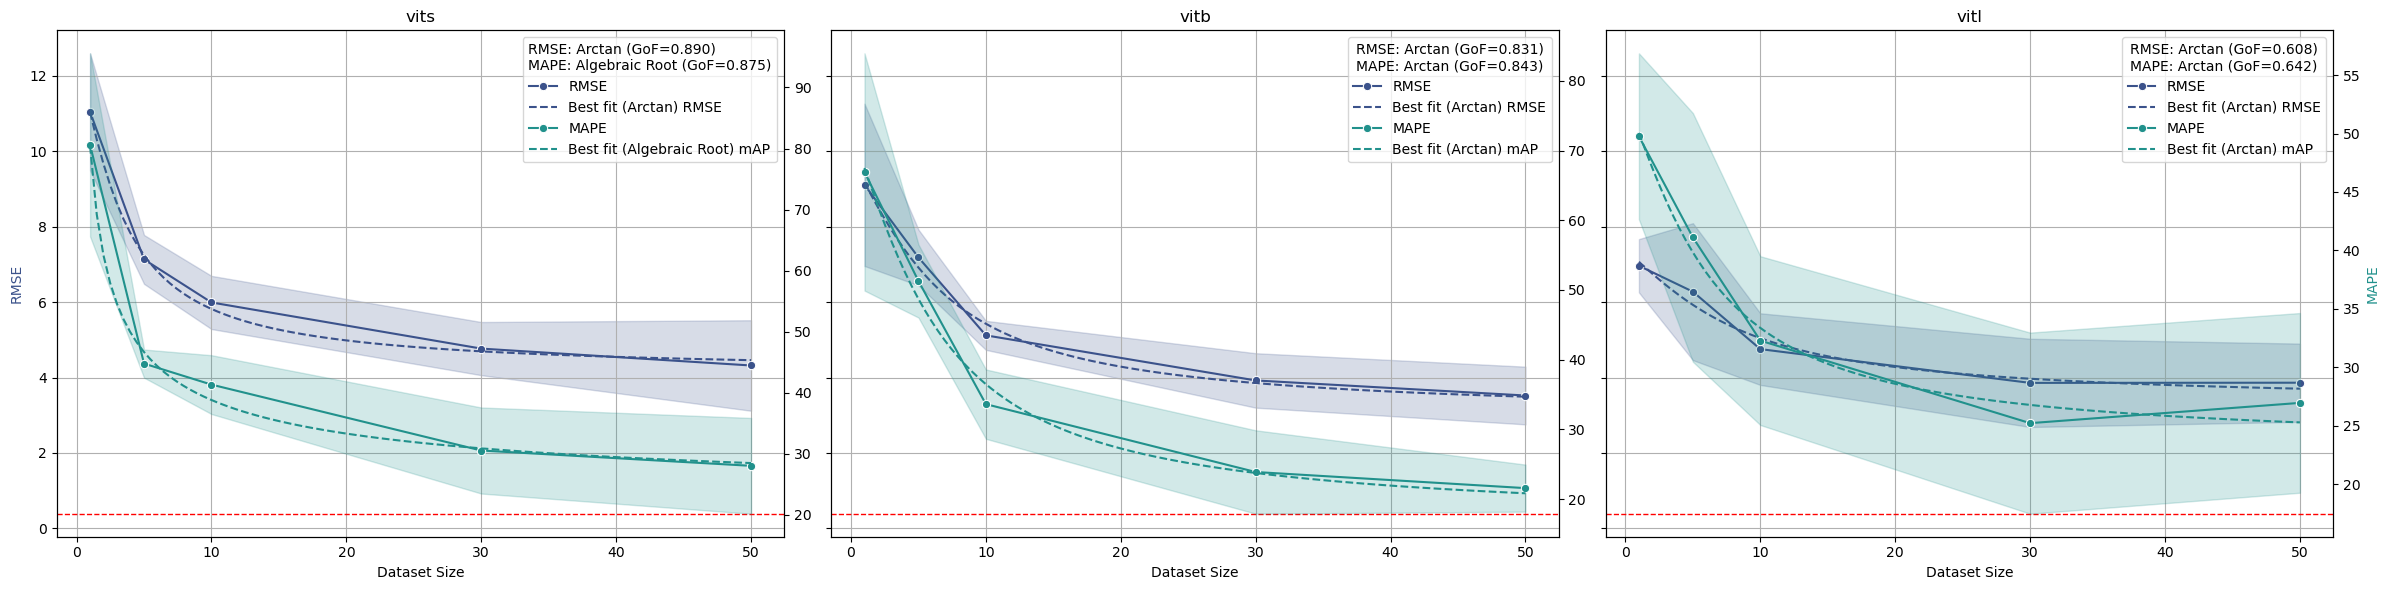

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

models = ['vits', 'vitb', 'vitl']

# Initialize the filtered DataFrame
filtered_df = results.copy()

# Set NaN values in the 'RMSE' column to 0
filtered_df['RMSE'] = filtered_df['RMSE'].fillna(0)

# Filter the DataFrame to include the specified models
filtered_df = filtered_df[filtered_df['Model'].isin(models)]

# Group by 'Dataset', 'model', and 'Dataset_size' and select the observation with the highest 'RMSE' value
filtered_df = filtered_df.loc[filtered_df.groupby(['Dataset', 'Model', 'Shots'])['RMSE'].idxmin()]

# Sort by Dataset size
filtered_df = filtered_df.sort_values(by='Shots')

# Define custom colors for each metric using the Viridis colormap
viridis = sns.color_palette("viridis", 3)
metric_colors = {'RMSE': viridis[0], 'MAPE': viridis[1]}

# Define fitting functions
def log_func(x, a, b):
    return a * np.log(x) + b

def arctan_func(x, a, b, c):
    return a * np.arctan(b * x) + c

def root_func(x, a, b, c):
    return a * np.power(x, 1/b) + c

# Create subplots
fig, axes = plt.subplots(1, len(models), figsize=(24, 6), sharey=True)

for i, (ax, model) in enumerate(zip(axes, models)):
    # Filter to single model
    model_data = filtered_df[filtered_df['Model'] == model]
    
    # Plot RMSE
    sns.lineplot(
        x='Shots', 
        y='RMSE', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['RMSE'],
        ax=ax,
        label='RMSE',
        legend=False
    )
    
    # Fit functions for RMSE vs Dataset_size
    x_data = model_data['Shots']
    y_data = model_data['RMSE']
    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
    
    # Initialize variables to track best fit
    best_r2_fit = None
    best_r2_score = -np.inf
    best_r2_name = ""
    
    # Try logarithmic fit
    try:
        popt_log, _ = curve_fit(log_func, x_data, y_data)
        y_fit_log = log_func(x_fit, *popt_log)
        r2_log = r2_score(y_data, log_func(x_data, *popt_log))
        if r2_log > best_r2_score:
            best_r2_fit = y_fit_log
            best_r2_score = r2_log
            best_r2_name = "Logarithmic"
    except:
        r2_log = -np.inf
    
    # Try arctan fit
    try:
        popt_arctan, _ = curve_fit(arctan_func, x_data, y_data)
        y_fit_arctan = arctan_func(x_fit, *popt_arctan)
        r2_arctan = r2_score(y_data, arctan_func(x_data, *popt_arctan))
        if r2_arctan > best_r2_score:
            best_r2_fit = y_fit_arctan
            best_r2_score = r2_arctan
            best_r2_name = "Arctan"
    except:
        r2_arctan = -np.inf
    
    # Try root fit
    try:
        p0 = [1, 2, 0]  # Initial parameter guess
        popt_root, _ = curve_fit(root_func, x_data, y_data, p0=p0)
        y_fit_root = root_func(x_fit, *popt_root)
        r2_root = r2_score(y_data, root_func(x_data, *popt_root))
        if r2_root > best_r2_score:
            best_r2_fit = y_fit_root
            best_r2_score = r2_root
            best_r2_name = "Algebraic Root"
    except:
        r2_root = -np.inf
    
    # Plot the best fit for RMSE
    ax.plot(x_fit, best_r2_fit, color=metric_colors['RMSE'], linestyle='--', 
            label=f'Best fit ({best_r2_name}) RMSE')
    
    # Create a twin Axes sharing the x-axis
    ax2 = ax.twinx()
    
    # Plot ap_iou_50_95
    sns.lineplot(
        x='Shots', 
        y='MAPE', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['MAPE'],
        ax=ax2,
        label='MAPE',
        legend=False
    )
    
    # Fit functions for ap_iou_50_95 vs Dataset_size
    y_data_ap = model_data['MAPE']
    
    # Initialize variables to track best fit
    best_ap_fit = None
    best_ap_score = -np.inf
    best_ap_name = ""
    
    # Try logarithmic fit
    try:
        popt_log_ap, _ = curve_fit(log_func, x_data, y_data_ap)
        y_fit_log_ap = log_func(x_fit, *popt_log_ap)
        r2_log_ap = r2_score(y_data_ap, log_func(x_data, *popt_log_ap))
        if r2_log_ap > best_ap_score:
            best_ap_fit = y_fit_log_ap
            best_ap_score = r2_log_ap
            best_ap_name = "Logarithmic"
    except:
        r2_log_ap = -np.inf
    
    # Try arctan fit
    try:
        popt_arctan_ap, _ = curve_fit(arctan_func, x_data, y_data_ap)
        y_fit_arctan_ap = arctan_func(x_fit, *popt_arctan_ap)
        r2_arctan_ap = r2_score(y_data_ap, arctan_func(x_data, *popt_arctan_ap))
        if r2_arctan_ap > best_ap_score:
            best_ap_fit = y_fit_arctan_ap
            best_ap_score = r2_arctan_ap
            best_ap_name = "Arctan"
    except:
        r2_arctan_ap = -np.inf
    
    # Try root fit
    try:
        popt_root_ap, _ = curve_fit(root_func, x_data, y_data_ap, p0=[1, 2, 0])
        y_fit_root_ap = root_func(x_fit, *popt_root_ap)
        r2_root_ap = r2_score(y_data_ap, root_func(x_data, *popt_root_ap))
        if r2_root_ap > best_ap_score:
            best_ap_fit = y_fit_root_ap
            best_ap_score = r2_root_ap
            best_ap_name = "Algebraic Root"
    except:
        r2_root_ap = -np.inf
    
    # Plot the best fit for ap_iou_50_95
    ax2.plot(x_fit, best_ap_fit, color=metric_colors['MAPE'], linestyle='--', 
             label=f'Best fit ({best_ap_name}) mAP')
    
    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    combined_lines = lines + lines2
    combined_labels = labels + labels2
    
    # Include best fit function name and R-squared in the legend title
    combined_title = f'RMSE: {best_r2_name} (GoF={best_r2_score:.3f})\nMAPE: {best_ap_name} (GoF={best_ap_score:.3f})'
    ax2.legend(combined_lines, combined_labels, title=combined_title, loc='upper right')
    
    ax.axhline(y=0.39, color='red', linestyle='--', linewidth=1)
    # ax.set_ylim(-1, 1)
    ax.set_title(f'{model}')
    ax.set_xlabel('Dataset Size')
    if i == 0:
        ax.set_ylabel('RMSE', color=metric_colors['RMSE'])
    else:
        ax.set_ylabel('')
    ax.grid(True)
    
    if i == len(models) - 1:
        ax2.set_ylabel('MAPE', color=metric_colors['MAPE'])
    else:
        ax2.set_ylabel('')
    ax2.grid(False)

plt.tight_layout()

# Save as PDF
plt.savefig('MDPI_template/Plots/rmse_ap_vs_shots_cdvito.pdf', format='pdf')
# plt.show()

In [ ]:
filtered_df